<div>
    <h1 align="center">"Optimizing Results"</h1></h1>
    <h1 align="center">Tabular Playground Series - Jan 2021</h1>
</div>

<div class="alert alert-success">  
</div>

## Description:
- In this notebook, we use the results of other notebooks. But in the end, the score of this notebook will be better than the score of each notebook used. Of course this type of method only works for some challenges and is not a general method.

- If we could test our answers unlimitedly (it means that there were no five tries limit per day), we would complete our notebook to automatically optimize the results of all kernels. In this case, even non-experts could optimize the results of the experts' work, and our notebook could approach the concept of "AutoML". But our method currently works only empirically as well as "trial and error".

- To date, I have used the results of twelve kernels. Of course, better scores have a greater impact on the score of this notebook. However, each kernel has helped me with the voting (Comparative Method). Thanks to everyone and again I will mention the addresses of some of these kernels below. Certainly the credit of this notebook belongs to all of us.

> https://www.kaggle.com/shogosuzuki/0-69701-folds-10-lightgbm

> https://www.kaggle.com/ryanzhang/tabular-playground-some-slightly-useful-features

> https://www.kaggle.com/hamzaghanmi/xgboost-hyperparameter-tuning-using-optuna

> https://www.kaggle.com/hamditarek/tabular-playground-series-xgboost-lightgbm

> https://www.kaggle.com/kailex/tabular-playground


<div class="alert alert-success">  
</div>

# If you find this work useful, please don't forget upvoting :)

# You can also find more information about this notebook at the following address:

# [[results-driven] How to convert a score of "0.69701" to a score of "0.69653".](http://www.kaggle.com/c/tabular-playground-series-jan-2021/discussion/213093)

https://www.kaggle.com/c/tabular-playground-series-jan-2021/discussion/213093

<div class="alert alert-success">  
</div>

## Import & Data Set

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

%matplotlib inline

# _______________________________________

# Kernels Data (Public Score & File Path)

dfk = pd.DataFrame({ 
    'Kernel ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'],  
    'Score':     [ 0.69864 , 0.69846 , 0.69836 , 0.69824 , 0.69813, 0.69795, 0.69751, 0.69749, 0.69747, 0.69735, 0.69731, 0.69701],   
    'File Path': ['../input/aa69864/AA69864.csv', '../input/bb69846/BB69846.csv', '../input/cc69836/CC69836.csv', '../input/a69824/A69824.csv', '../input/c69813/C69813.csv', '../input/ff69795/FF69795.csv', '../input/gg69751/GG69751.csv' , '../input/g69749/G69749.csv', '../input/h69747/H69747.csv', '../input/i69735/I69735.csv', '../input/j69731/J69731.csv', '../input/l69701/L69701.csv']     
})    
    
dfk         

,Kernel ID,Score,File Path
0,A,0.69864,../input/aa69864/AA69864.csv
1,B,0.69846,../input/bb69846/BB69846.csv
2,C,0.69836,../input/cc69836/CC69836.csv
3,D,0.69824,../input/a69824/A69824.csv
4,E,0.69813,../input/c69813/C69813.csv
5,F,0.69795,../input/ff69795/FF69795.csv
6,G,0.69751,../input/gg69751/GG69751.csv
7,H,0.69749,../input/g69749/G69749.csv
8,I,0.69747,../input/h69747/H69747.csv
9,J,0.69735,../input/i69735/I69735.csv


<div class="alert alert-success">  
</div>

## Functions:

In [2]:
def generate(main, support, coeff):
    
    g = main.copy()    
    for i in main.columns[1:]:
        
        res = []
        lm, Is = [], []        
        lm = main[i].tolist()
        ls = support[i].tolist()  
        
        for j in range(len(main)):
            res.append((lm[j] * coeff) + (ls[j] * (1.- coeff)))            
        g[i] = res
        
    return g


In [3]:
def drawing(main, support, generated):
    
    X  = main.iloc[:, 1]
    Y1 = support.iloc[:, 1]
    Y2 = generated.iloc[:, 1]
    
    plt.style.use('seaborn-whitegrid') 
    plt.figure(figsize=(8, 8), facecolor='lightgray')
    plt.title(f'\nOn the X axis >>> main\nOn the Y axis >>> support\n')           
    plt.scatter(X, Y1, s=0.1)
    plt.show() 
    
    plt.style.use('seaborn-whitegrid') 
    plt.figure(figsize=(8, 8), facecolor='lightgray')
    plt.title(f'\nOn the X axis >>> main\nOn the Y axis >>> generated\n')           
    plt.scatter(X, Y2, s=0.1)
    plt.show()     
    

In [4]:
def drawing1(main, support, generated):
    
    X  = main.iloc[:, 1]
    Y1 = support.iloc[:, 1]
    Y2 = generated.iloc[:, 1]
    
    plt.style.use('seaborn-whitegrid') 
    plt.figure(figsize=(8, 8), facecolor='lightgray')
    plt.title(f'\nBlue | X axis >> main | Y axis >> support\n\nOrange | X axis >> main | Y axis >> generated\n') 
    
    plt.scatter(X, Y1, s=0.1)    
    plt.scatter(X, Y2, s=0.1)
    
    plt.show() 
    

In [5]:
def drawing2(pxy, mxy):
    
    plt.style.use('seaborn-whitegrid') 
    plt.figure(figsize=(8, 8), facecolor='lightgray')
    plt.title(f'\nComparative Method\n\nBlue | X(main) | Y(average - smaller result)\n\nOrange | X(main) | Y(generated)\n') 
    plt.scatter(pxy[0], pxy[1], s=0.1)
    plt.scatter(pxy[0], pxy[2], s=0.1)
    plt.show() 

    plt.style.use('seaborn-whitegrid') 
    plt.figure(figsize=(8, 8), facecolor='lightgray')
    plt.title(f'\nComparative Method\n\nBlue | X(main) | Y(average - bigger results)\n\nOrange | X(main) | Y(generated)\n') 
    plt.scatter(mxy[0], mxy[1], s=0.1)
    plt.scatter(mxy[0], mxy[2], s=0.1)
    plt.show()
    

In [6]:
def comparison(main, majority, pcoeff, mcoeff):
    
    comp = main.copy()
    for i in main.columns[1:]:
        res = []
        pxy = [[],[],[]]
        mxy = [[],[],[]]        
        lm  = main[i].tolist() 
        ls  = [[],[],[],[],[],[],[],[],[],[],[],[]]
        for n in range (12):       
            csv   = pd.read_csv(dfk.iloc[n, 2])  
            ls[n] = csv[i].tolist() 
            
        for j in range(len(main)):
            pcount = 0
            pvalue = 0.0        
            mcount = 0
            mvalue = 0.0 
    
            for k in range (12):            
                if lm[j] > ls[k][j]:
                    pcount += 1
                    pvalue += ls[k][j]                 
                else: 
                    mcount += 1
                    mvalue += ls[k][j] 
                    
            if (pcount > majority): 
                res.append(lm[j] * pcoeff)
                pxy[2].append(lm[j] * pcoeff)                
                pxy[1].append(pvalue / pcount)
                pxy[0].append(lm[j])
                        
            elif (mcount > majority): 
                res.append(lm[j] * mcoeff)
                mxy[2].append(lm[j] * mcoeff)                
                mxy[1].append(mvalue / mcount)
                mxy[0].append(lm[j])
                        
            else: 
                res.append(lm[j])       
    
        comp[i] = res    

    drawing2(pxy, mxy)    
    return comp
    
    

<div class="alert alert-success">  
</div>

## Step #1
In this step, we use the results of kernels "A, B, C, D, E, F, G".

In [7]:
support = pd.read_csv(dfk.iloc[0, 2])
    
for k in range (1, 7):
    main = pd.read_csv(dfk.iloc[k, 2])
    support = generate(main, support, 0.99)
    
sub1 = support 

## Result: 
[ A: (Score: 0.69864), B: (Score: 0.69846), ... , G: (Score: 0.69795), H: (Score: 0.69751) ] >>> sub1: (Score: **0.69751**)

The results of these kernels are used in the "Comparative Method" and can not have a direct effect on improving the score.


In [8]:
print('sub1(Last Support)    | Score: 0.69751')
sub1.describe()

sub1(Last Support)    | Score: 0.69751


,id,target
count,200000.000000,200000.000000
mean,250261.031215,7.905119
std,144128.894365,0.220601
min,0.000000,7.096478
25%,125538.250000,7.755090
50%,250389.500000,7.894569
75%,375240.250000,8.042514
max,499990.000000,9.505738


<div class="alert alert-success">  
</div>

## Step #2
Use the results of the "H" kernel as well as the results of step #1.

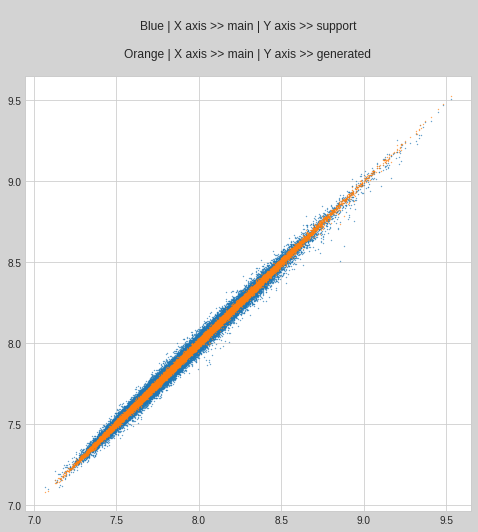

In [9]:
main = pd.read_csv(dfk.iloc[7, 2])

sub2 = generate(main, sub1, 0.65)

#drawing(main, sub1, sub2)

drawing1(main, sub1, sub2)

## Result:

[ H: (Score: 0.69749) , sub1: (Score: 0.69751) ] >>> sub2: (Score: **0.69744**)

In [10]:
print('sub2    | Score: 0.69744')
sub2.describe()

sub2    | Score: 0.69744


,id,target
count,200000.000000,200000.000000
mean,250261.031215,7.905132
std,144128.894365,0.221174
min,0.000000,7.082065
25%,125538.250000,7.754698
50%,250389.500000,7.894398
75%,375240.250000,8.042438
max,499990.000000,9.520862


<div class="alert alert-success">  
</div>

## Step #3
Use the results of the "I" kernel as well as the results of step #2.

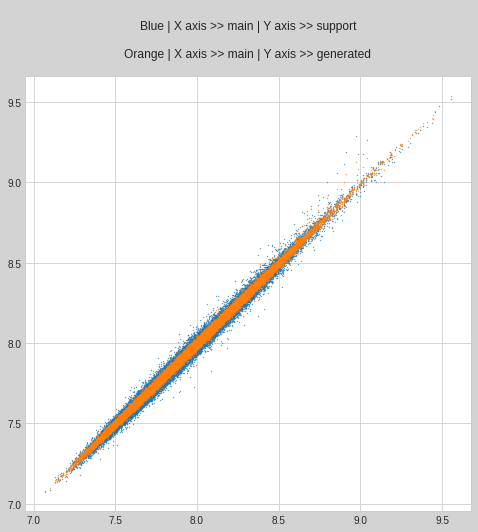

In [11]:
main = pd.read_csv(dfk.iloc[8, 2])

sub3 = generate(main, sub2, 0.50)

#drawing(main, sub2, sub3)

drawing1(main, sub2, sub3)

## Result:

[ I: (Score: 0.69747) , sub2: (Score: 0.69744) ] >>> sub3: (Score: **0.69737**)


In [12]:
print('sub3    | Score: 0.69737')
sub3.describe()

sub3    | Score: 0.69737


,id,target
count,200000.000000,200000.000000
mean,250261.031215,7.908667
std,144128.894365,0.220001
min,0.000000,7.076134
25%,125538.250000,7.759325
50%,250389.500000,7.898282
75%,375240.250000,8.045035
max,499990.000000,9.536806


<div class="alert alert-success">  
</div>

## Step #4
Use the results of the "J" kernel as well as the results of step #3.

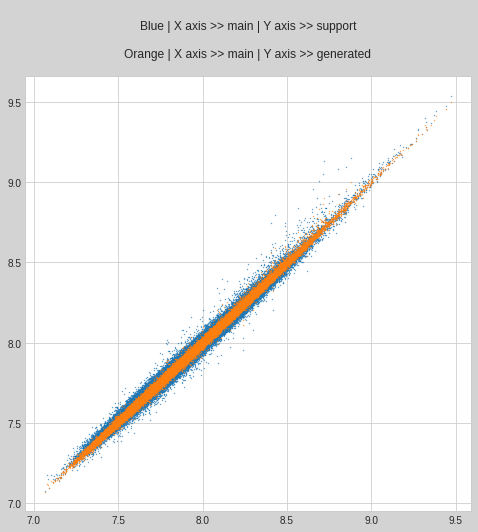

In [13]:
main = pd.read_csv(dfk.iloc[9, 2])

sub4 = generate(main, sub3, 0.55)

#drawing(main, sub3, sub4)

drawing1(main, sub3, sub4)

## Result:

[ J: (Score: 0.69735) , sub3: (Score: 0.69737) ] >>> sub4: (Score: **0.69725**)


In [14]:
print('sub4    | Score: 0.69725')
sub4.describe()

sub4    | Score: 0.69725


,id,target
count,200000.000000,200000.000000
mean,250261.031215,7.906712
std,144128.894365,0.222245
min,0.000000,7.071076
25%,125538.250000,7.755653
50%,250389.500000,7.896751
75%,375240.250000,8.045477
max,499990.000000,9.499923


<div class="alert alert-success">  
</div>

## Step #5
Use the results of the "K" kernel as well as the results of step #4.

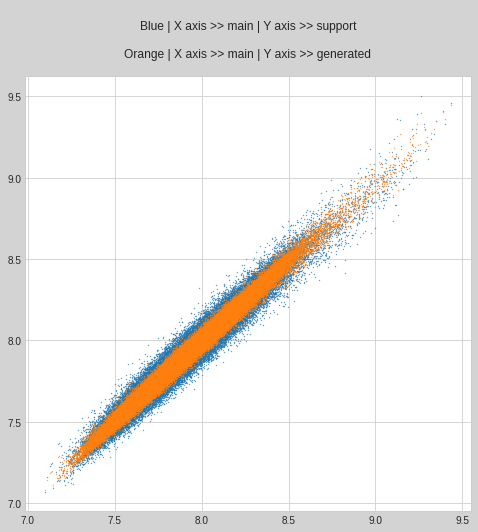

In [15]:
main = pd.read_csv(dfk.iloc[10, 2])

sub5 = generate(main, sub4, 0.43)

#drawing(main, sub4, sub5)

drawing1(main, sub4, sub5)

## Result:

[ K: (Score: 0.69731) , sub4: (Score: 0.69725) ] >>> sub5: (Score: **0.69687**)

The difference in solutions between the two notebooks is the reason for the good progress at this stage. When solutions are different, they reinforce each other's weaknesses.


In [16]:
print('sub5    | Score: 0.69687')
sub5.describe()

sub5    | Score: 0.69687


,id,target
count,200000.000000,200000.000000
mean,250261.031215,7.906127
std,144128.894365,0.221020
min,0.000000,7.082672
25%,125538.250000,7.755616
50%,250389.500000,7.895861
75%,375240.250000,8.043839
max,499990.000000,9.448086


<div class="alert alert-success">  
</div>

## Step #6
Use the results of the "L" kernel as well as the results of step #5.

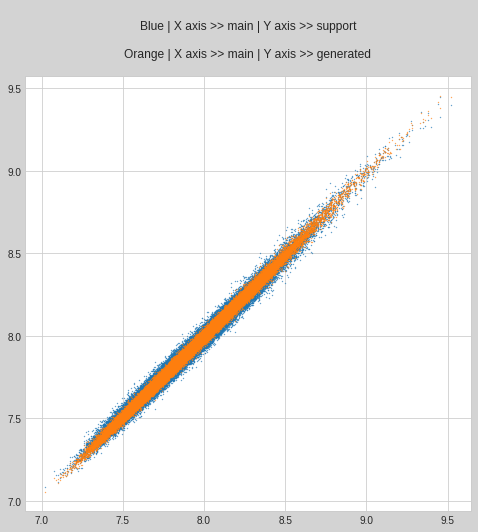

In [17]:
main = pd.read_csv(dfk.iloc[11, 2])

sub6 = generate(main, sub5, 0.40)

#drawing(main, sub5, sub6)

drawing1(main, sub5, sub6)

## Result:

[ Ł: (Score: 0.69701) , sub5: (Score: 0.69687) ] >>> sub6: (Score: **0.69680**)

In [18]:
print('sub6    | Score: 0.69680')
sub6.describe()

sub6    | Score: 0.69680


,id,target
count,200000.000000,200000.000000
mean,250261.031215,7.905688
std,144128.894365,0.223407
min,0.000000,7.057754
25%,125538.250000,7.753585
50%,250389.500000,7.895696
75%,375240.250000,8.045265
max,499990.000000,9.451351


<div class="alert alert-success">  
</div>

## Step #7
## Comparative Method
In this step, we so-called recover some of the results of the previous step. That is, we compensate for the bad effects of the previous stages.

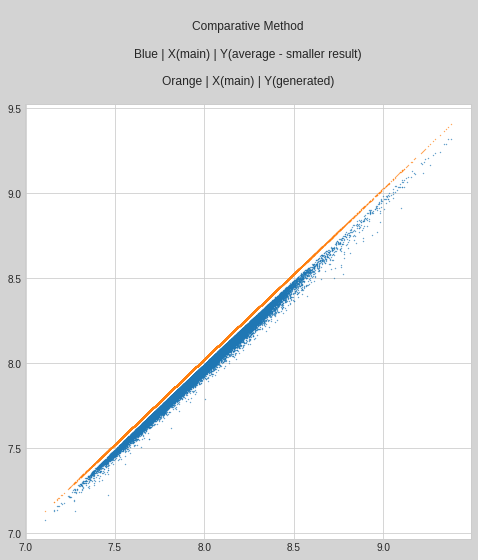

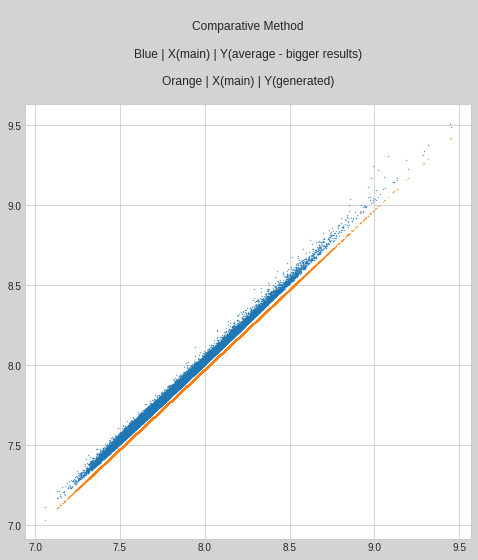

In [19]:
sub7 = comparison(sub6, 7, 1.0032, 0.9968)


## Result:

sub6: (Score: 0.69680)  >>>  sub7: (Score: **0.69656**)

We first compared the result of our previous step with the results of each kernel used. We looked for rows where the results of all kernels (or the majority of kernels) differed from the results of our previous step (more or less). On the other hand, we know that the results of the previous step are better than the results of all the kernels used. So we can guess that these rows have been oppressed !!! That is, in the previous steps, they were mistakenly increased or decreased. We compensate for these possible errors to some extent by applying the coefficients "pcoeff" and "mcoeff" (of course, only in these rows). Fortunately, the pictures illustrate the method well.

That is, first we hold a vote and then, exactly contrary to the result of the vote, we make the corrections:)

In [20]:
print('sub7    | Score: 0.69656')
sub7.describe()

sub7    | Score: 0.69656


,id,target
count,200000.000000,200000.000000
mean,250261.031215,7.905309
std,144128.894365,0.228526
min,0.000000,7.035169
25%,125538.250000,7.749283
50%,250389.500000,7.896220
75%,375240.250000,8.049870
max,499990.000000,9.421107


<div class="alert alert-success">  
</div>

## Submission

In [21]:
sub = sub7
sub.to_csv("submission.csv", index=False)

sub1.to_csv("submission1.csv", index=False)
sub2.to_csv("submission2.csv", index=False)
sub3.to_csv("submission3.csv", index=False)
sub4.to_csv("submission4.csv", index=False)
sub5.to_csv("submission5.csv", index=False)
sub6.to_csv("submission6.csv", index=False)

!ls

__notebook__.ipynb  submission1.csv  submission3.csv  submission5.csv
submission.csv	    submission2.csv  submission4.csv  submission6.csv


<div class="alert alert-success">  
</div>

## Conclusion:
### In this notebook, only the results of a number of kernels were used. The best score was "0.69701". But as you can see, we were able to score much better. >>> "Score: 0.69656"

<div class="alert alert-success">  
</div>